# Working with Text and Text Analytics

By: Dr. Eric Godat

So far in this bootcamp we have worked with:

- numbers
- tables
- maps
- geographic data

But a huge amount of real-world data is actually text.

Reviews, news articles, social media posts, interview transcripts,
emails, books, and surveys are all forms of text data.

Today we will explore:

- cleaning text
- counting words and phrases
- extracting patterns from language
- identifying important words in documents
- some limitations of text analysis

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import string

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# Apartment Reviews — Text as Data

Let’s start with a small dataset of apartment reviews.

Unlike numerical data, text is:

- messy
- inconsistent
- emotional
- ambiguous

But we can still analyze it computationally.

In [2]:
reviews = pd.DataFrame({
    "Apartment":[
        "Mustang Station",
        "Campus View",
        "Highland House",
        "Mockingbird Flats",
        "Hilltop Lofts",
        "University Crossing",
        "Maple Terrace",
        "Lakeside Apartments"
    ],

    "Stars":[
        2,4,1,5,3,2,4,1
    ],

    "Review":[
        "The location is honestly great if you need to get to campus quickly, but the walls are paper thin and people are constantly yelling outside at like 2am.",

        "Pretty solid place overall. Cheap rent, decent kitchen, and I can walk to class in about 10 minutes. Maintenance is slow sometimes though.",

        "I would absolutely not live here again. My AC broke twice during August and management stopped answering emails after the first week.",

        "Loved living here. The staff remembered my name, the study rooms were actually useful, and the coffee shop downstairs became my second home.",

        "The apartment itself is nice enough and I like the gym, but parking is frustrating and guest parking is basically impossible on weekends.",

        "Moved in because it looked nice on the tour but the wifi cuts out constantly and my roommate found mold behind the kitchen cabinet midway through the semester.",

        "Honestly surprised by how much I liked this place. Quiet, clean, good lighting, and my dog was weirdly happier here than our last apartment.",

        "One night the fire alarm went off three times between midnight and 4am and nobody from management explained what happened. Also saw two cockroaches in the kitchen."
    ]
})

reviews

,Apartment,Stars,Review
0,Mustang Station,2,The location is honestly great if you need to ...
1,Campus View,4,"Pretty solid place overall. Cheap rent, decent..."
2,Highland House,1,I would absolutely not live here again. My AC ...
3,Mockingbird Flats,5,Loved living here. The staff remembered my nam...
4,Hilltop Lofts,3,The apartment itself is nice enough and I like...
5,University Crossing,2,Moved in because it looked nice on the tour bu...
6,Maple Terrace,4,Honestly surprised by how much I liked this pl...
7,Lakeside Apartments,1,One night the fire alarm went off three times ...


# Word Counts

One of the simplest things we can measure is document length.

In [3]:
reviews["word_count"] = (
    reviews["Review"]
    .str.split()
    .str.len()
)

reviews[["Apartment","word_count"]]

,Apartment,word_count
0,Mustang Station,28
1,Campus View,23
2,Highland House,22
3,Mockingbird Flats,23
4,Hilltop Lofts,23
5,University Crossing,28
6,Maple Terrace,24
7,Lakeside Apartments,27


In [4]:
reviews.sort_values(by="word_count", ascending=False)

,Apartment,Stars,Review,word_count
0,Mustang Station,2,The location is honestly great if you need to ...,28
5,University Crossing,2,Moved in because it looked nice on the tour bu...,28
7,Lakeside Apartments,1,One night the fire alarm went off three times ...,27
6,Maple Terrace,4,Honestly surprised by how much I liked this pl...,24
1,Campus View,4,"Pretty solid place overall. Cheap rent, decent...",23
3,Mockingbird Flats,5,Loved living here. The staff remembered my nam...,23
4,Hilltop Lofts,3,The apartment itself is nice enough and I like...,23
2,Highland House,1,I would absolutely not live here again. My AC ...,22


# Character Counts

In [5]:
reviews["char_count"] = reviews["Review"].str.len()

reviews[["Apartment","char_count"]]

,Apartment,char_count
0,Mustang Station,152
1,Campus View,138
2,Highland House,133
3,Mockingbird Flats,140
4,Hilltop Lofts,137
5,University Crossing,159
6,Maple Terrace,140
7,Lakeside Apartments,163


# Most Common Words

Now let’s combine all the reviews together and count the most common
words.

In [6]:
all_words = " ".join(reviews["Review"]).lower().split()

Counter(all_words).most_common(15)

[('the', 14),
 ('and', 10),
 ('is', 5),
 ('my', 5),
 ('i', 4),
 ('to', 3),
 ('but', 3),
 ('in', 3),
 ('honestly', 2),
 ('are', 2),
 ('constantly', 2),
 ('like', 2),
 ('here', 2),
 ('management', 2),
 ('nice', 2)]

Some of these words are useful.

Some are extremely common and do not tell us very much.

# Cleaning Text

Before analyzing text, we usually clean it.

This often includes:

- lowercasing
- removing punctuation
- removing stopwords

## Lowercase

In [7]:
reviews["clean_review"] = (
    reviews["Review"]
    .str.lower()
)

reviews["clean_review"].head()

0    the location is honestly great if you need to ...
1    pretty solid place overall. cheap rent, decent...
2    i would absolutely not live here again. my ac ...
3    loved living here. the staff remembered my nam...
4    the apartment itself is nice enough and i like...
Name: clean_review, dtype: object

## Remove Punctuation

In [8]:
reviews["clean_review"] = (
    reviews["clean_review"]
    .str.translate(
        str.maketrans("", "", string.punctuation)
    )
)

reviews["clean_review"].head()

0    the location is honestly great if you need to ...
1    pretty solid place overall cheap rent decent k...
2    i would absolutely not live here again my ac b...
3    loved living here the staff remembered my name...
4    the apartment itself is nice enough and i like...
Name: clean_review, dtype: object

## Stopwords

Stopwords are very common words like:

- the
- and
- is
- of

These words are often removed because they carry little meaning by
themselves.

In [9]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)

In [10]:
reviews["clean_review"] = reviews["clean_review"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stopwords
    )
)

reviews["clean_review"].head()

0    location honestly great need campus quickly wa...
1    pretty solid place overall cheap rent decent k...
2    absolutely live ac broke twice august manageme...
3    loved living staff remembered study rooms actu...
4    apartment nice like gym parking frustrating gu...
Name: clean_review, dtype: object

# Most Common Cleaned Words

In [11]:
clean_words = " ".join(
    reviews["clean_review"]
).split()

Counter(clean_words).most_common(15)

[('kitchen', 3),
 ('honestly', 2),
 ('constantly', 2),
 ('like', 2),
 ('place', 2),
 ('management', 2),
 ('apartment', 2),
 ('nice', 2),
 ('parking', 2),
 ('location', 1),
 ('great', 1),
 ('need', 1),
 ('campus', 1),
 ('quickly', 1),
 ('walls', 1)]

# Visualizing Word Counts

In [12]:
common_words = pd.DataFrame(
    Counter(clean_words).most_common(10),
    columns=["word","count"]
)

<Axes: title={'center': 'Most Common Words in Apartment Reviews'}, xlabel='word'>

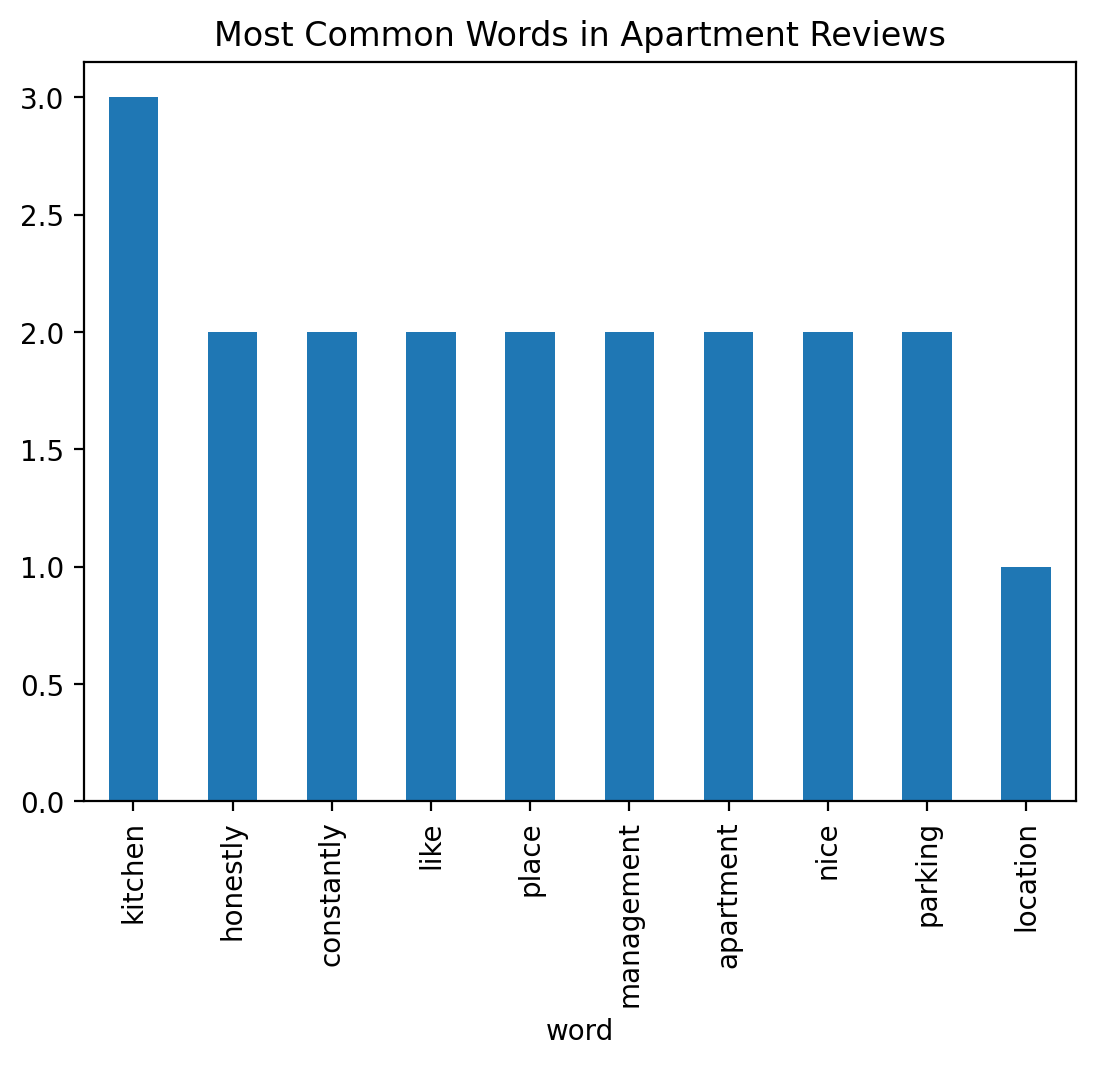

In [13]:
common_words.plot.bar(
    x="word",
    y="count",
    legend=False,
    title="Most Common Words in Apartment Reviews"
)

# You Try

Pick one apartment review and answer:

1.  Does the cleaned version preserve the meaning of the original
    review?
2.  What information was removed?
3.  What information became easier to analyze?

# Limits of Word Counts

Consider these two sentences:

- “dog bites man”
- “man bites dog”

A simple word count treats these as almost identical.

But they clearly mean very different things.

Word order matters.

# Folktales Dataset

Now let’s move to a larger and more complicated text dataset.

In [14]:
folktales = pd.read_csv("folktales.csv")

folktales.head()

,Unnamed: 0,ATU Code,Author,Country of Origin,Original Title,Source,Story,Story Type,Title,Translated,Year Translated,Year Written
0,17,15.0,Jacob & Wilhelm Grimm,Germany,Katze und Maus in Gesellschaft,NaN,"A cat had made the acquaintance of a mouse, an...",Stealing the Partner's Butter (ATU 15)\n\t\t,Cat and mouse in partnership,Margaret Hunt,1884.0,1812
1,44,123.0,Jacob & Wilhelm Grimm,Germany,Der Wolf und die sieben jungen Geisslein,NaN,There was once an old goat who had seven littl...,The Wolf and the Seven Young Kids (ATU 123)\n...,The Wolf and the Seven Young Kids,Margaret Hunt,1884.0,1812
2,54,516.0,Jacob & Wilhelm Grimm,Germany,Der treue Johannes,The Blue Fairy Book (nr. 30),ONCE upon a time there was an old king who was...,The Petrified Friend (ATU 516)\n\t\t,Trusty John,Andrew Lang,1889.0,1812
3,64,NaN,Jacob & Wilhelm Grimm,Germany,Der gute Handel,NaN,There was once a peasant who had driven his co...,NaN,The good bargain,Margaret Hunt,1884.0,1812
4,74,151.0,Jacob & Wilhelm Grimm,Germany,Der wunderliche Spielmann,NaN,"There was once a wonderful musician, who went ...",Music lessons for wild animals (ATU 151)\n\t\t,The Wonderful Musician,Translated into English,NaN,1812


# Exploring the Dataset

In [15]:
folktales.columns

Index(['Unnamed: 0', 'ATU Code', 'Author', 'Country of Origin',
       'Original Title', 'Source', 'Story', 'Story Type', 'Title',
       'Translated', 'Year Translated', 'Year Written'],
      dtype='object')

In [16]:
folktales["Country of Origin"].value_counts().head(10)

Country of Origin
Greece              202
Germany             159
Denmark             138
Italy               115
Norway               99
France               79
Russia               58
Spain                 9
Spain   - Region      6
Iceland               6
Name: count, dtype: int64

In [17]:
folktales[["Title", "Author", "Country of Origin", "Story Type"]].head()

,Title,Author,Country of Origin,Story Type
0,Cat and mouse in partnership,Jacob & Wilhelm Grimm,Germany,Stealing the Partner's Butter (ATU 15)\n\t\t
1,The Wolf and the Seven Young Kids,Jacob & Wilhelm Grimm,Germany,The Wolf and the Seven Young Kids (ATU 123)\n...
2,Trusty John,Jacob & Wilhelm Grimm,Germany,The Petrified Friend (ATU 516)\n\t\t
3,The good bargain,Jacob & Wilhelm Grimm,Germany,NaN
4,The Wonderful Musician,Jacob & Wilhelm Grimm,Germany,Music lessons for wild animals (ATU 151)\n\t\t


# Select a Familiar Story

We’ll focus on Cinderella because:

- it is culturally recognizable
- it contains repeated motifs
- it is long enough for analysis
- it has strong thematic vocabulary

In [18]:
cinderella = folktales[
    folktales["Title"].str.contains(
        "Cinderella",
        case=False,
        na=False
    )
]

cinderella[["Title","Country of Origin", "Author", "Story Type"]]

,Title,Country of Origin,Author,Story Type
13,Cinderella,Germany,Jacob & Wilhelm Grimm,NaN
427,"Cinderella; or, The Little Glass Slipper",France,Charles Perrault,Persecuted Heroine (ATU 510A)\n\t\t


# Extract Story Text

In [19]:
story = cinderella.iloc[1]["Story"]

story[:1000]

"Once there was a gentleman who married, for his second wife, the proudest and most haughty woman that was ever seen. She had, by a former husband, two daughters of her own, who were, indeed, exactly like her in all things. He had likewise, by another wife, a young daughter, but of unparalleled goodness and sweetness of temper, which she took from her mother, who was the best creature in the world.No sooner were the ceremonies of the wedding over but the stepmother began to show herself in her true colors. She could not bear the good qualities of this pretty girl, and the less because they made her own daughters appear the more odious. She employed her in the meanest work of the house. She scoured the dishes, tables, etc., and cleaned madam's chamber, and those of misses, her daughters. She slept in a sorry garret, on a wretched straw bed, while her sisters slept in fine rooms, with floors all inlaid, on beds of the very newest fashion, and where they had looking glasses so large that 

# Clean the Story

In [20]:
story_clean = story.lower()

In [21]:
story_clean = story_clean.translate(
    str.maketrans(
        string.punctuation,
        " " * len(string.punctuation)
    )
)
story_clean = " ".join(story_clean.split())

story_clean[:1000]

'once there was a gentleman who married for his second wife the proudest and most haughty woman that was ever seen she had by a former husband two daughters of her own who were indeed exactly like her in all things he had likewise by another wife a young daughter but of unparalleled goodness and sweetness of temper which she took from her mother who was the best creature in the world no sooner were the ceremonies of the wedding over but the stepmother began to show herself in her true colors she could not bear the good qualities of this pretty girl and the less because they made her own daughters appear the more odious she employed her in the meanest work of the house she scoured the dishes tables etc and cleaned madam s chamber and those of misses her daughters she slept in a sorry garret on a wretched straw bed while her sisters slept in fine rooms with floors all inlaid on beds of the very newest fashion and where they had looking glasses so large that they could see themselves at t

In [22]:
story_clean = " ".join(
    word for word in story_clean.split()
    if word not in stopwords
)

story_clean[:1000]

'gentleman married second wife proudest haughty woman seen husband daughters exactly like things likewise wife young daughter unparalleled goodness sweetness temper took mother best creature world sooner ceremonies wedding stepmother began true colors bear good qualities pretty girl daughters appear odious employed meanest work house scoured dishes tables cleaned madam s chamber misses daughters slept sorry garret wretched straw bed sisters slept fine rooms floors inlaid beds newest fashion looking glasses large length head foot poor girl bore patiently dared tell father scolded wife governed entirely work used chimney corner sit cinders ashes caused called cinderwench younger sister rude uncivil older called cinderella cinderella notwithstanding coarse apparel times beautiful sisters dressed richly happened king s son gave ball invited persons fashion young misses invited cut grand figure quality mightily delighted invitation wonderfully busy selecting gowns petticoats hair dressing b

# Word Frequencies

In [23]:
story_words = story_clean.split()

Counter(story_words).most_common(20)

[('cinderella', 28),
 ('said', 16),
 ('godmother', 16),
 ('ball', 14),
 ('sisters', 13),
 ('s', 12),
 ('beautiful', 11),
 ('fine', 9),
 ('king', 9),
 ('son', 8),
 ('good', 7),
 ('gave', 7),
 ('day', 7),
 ('slipper', 7),
 ('seen', 6),
 ('young', 6),
 ('dressed', 6),
 ('went', 6),
 ('clothes', 6),
 ('world', 5)]

These are some of the most common meaningful words in the story.

In [24]:
cinderella_words = pd.DataFrame(
    Counter(story_words).most_common(15),
    columns=["word", "count"]
)

<Axes: title={'center': 'Most Common Words in Cinderella'}, xlabel='word'>

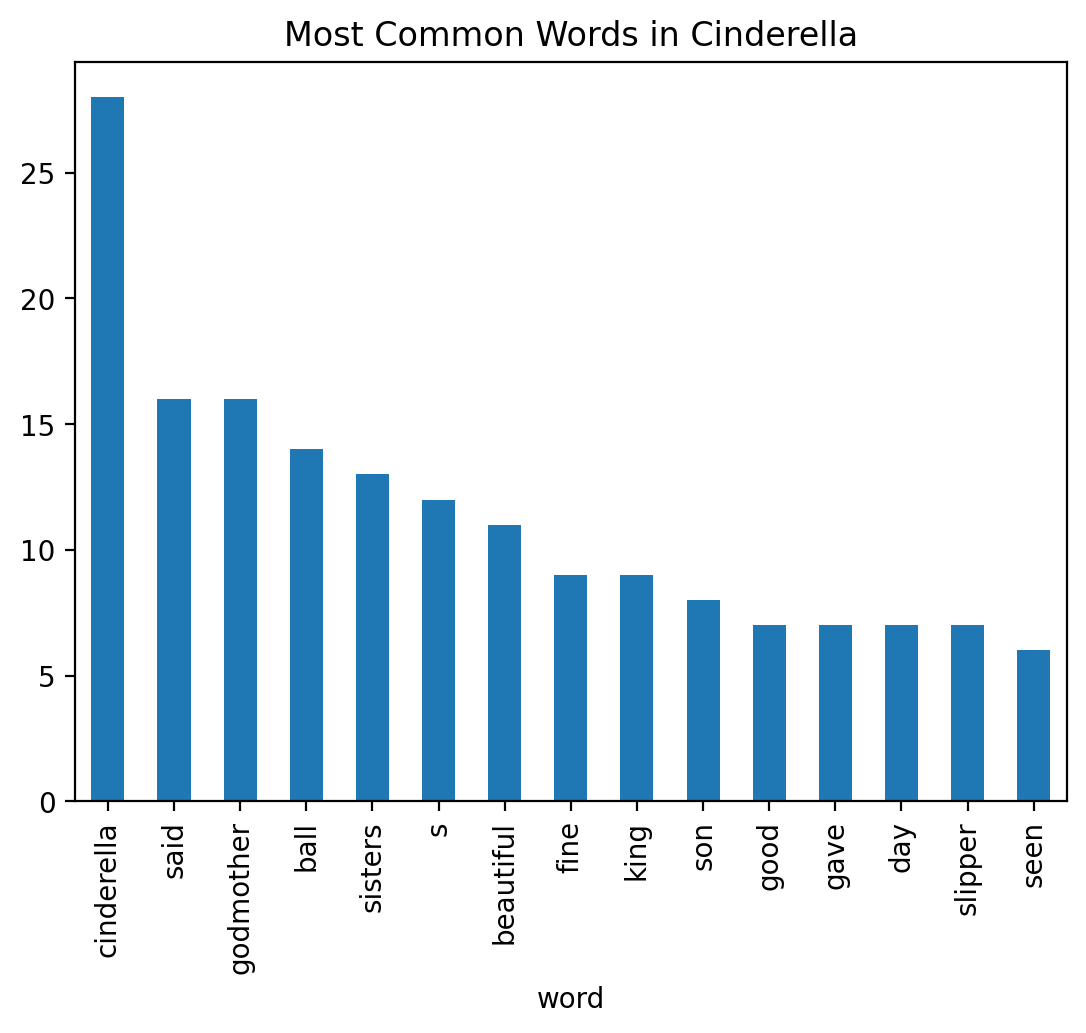

In [25]:
cinderella_words.plot.bar(
    x="word",
    y="count",
    legend=False,
    title="Most Common Words in Cinderella"
)

# N-grams

Single words can be useful, but phrases can reveal more structure.

An n-gram is a sequence of words.

Today we will focus on:

- bigrams, or 2-word phrases

In [26]:
from nltk import ngrams

In [27]:
bigrams = list(
    ngrams(story_words, 2)
)

Counter(bigrams).most_common(15)

[(('king', 's'), 8),
 (('s', 'son'), 8),
 (('ball', 'cinderella'), 3),
 (('touched', 'wand'), 3),
 (('glass', 'slippers'), 3),
 (('said', 'cinderella'), 2),
 (('right', 'replied'), 2),
 (('fairy', 'said'), 2),
 (('wish', 'ball'), 2),
 (('yes', 'cried'), 2),
 (('turned', 'fine'), 2),
 (('gold', 'silver'), 2),
 (('godmother', 'touched'), 2),
 (('slippers', 'prettiest'), 2),
 (('prettiest', 'world'), 2)]

# Why N-grams Matter

N-grams preserve some word order information.

For example:

- “king's son”
- “touched wand”
- “glass slippers”

can reveal themes that single words might miss.

# TF-IDF

Word frequency tells us what words are common.

But what words make a story unique?

TF-IDF helps identify words that are:

- common in one document
- uncommon across the whole collection

In plain language:

- **TF** asks: What words appear often in this story?
- **IDF** asks: What words are rare across all stories?
- **TF-IDF** asks: What words help make this story distinctive?

This idea is closely related to how search engines and recommendation
systems identify important terms in documents.

# TF-IDF with Scikit-Learn

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

In [30]:
matrix = tfidf.fit_transform(
    folktales["Story"].fillna("")
)

In [31]:
matrix.shape

(908, 5000)

# Most Important Words in Cinderella

In [32]:
story_index = cinderella.index[1]

In [33]:
feature_names = tfidf.get_feature_names_out()

scores = matrix[story_index].toarray()[0]

important_words = pd.DataFrame({
    "word": feature_names,
    "score": scores
})

important_words.sort_values(
    by="score",
    ascending=False
).head(20)

,word,score
754,cinderella,0.697313
1880,godmother,0.384628
255,ball,0.212715
3945,sisters,0.185666
3979,slipper,0.142353
4772,wand,0.094327
308,beautiful,0.093909
807,coach,0.083051
1594,fine,0.082662
3689,said,0.078031


# Compare Word Frequency and TF-IDF

<Axes: title={'center': 'Most Distinctive Words in Cinderella by TF-IDF'}, xlabel='word'>

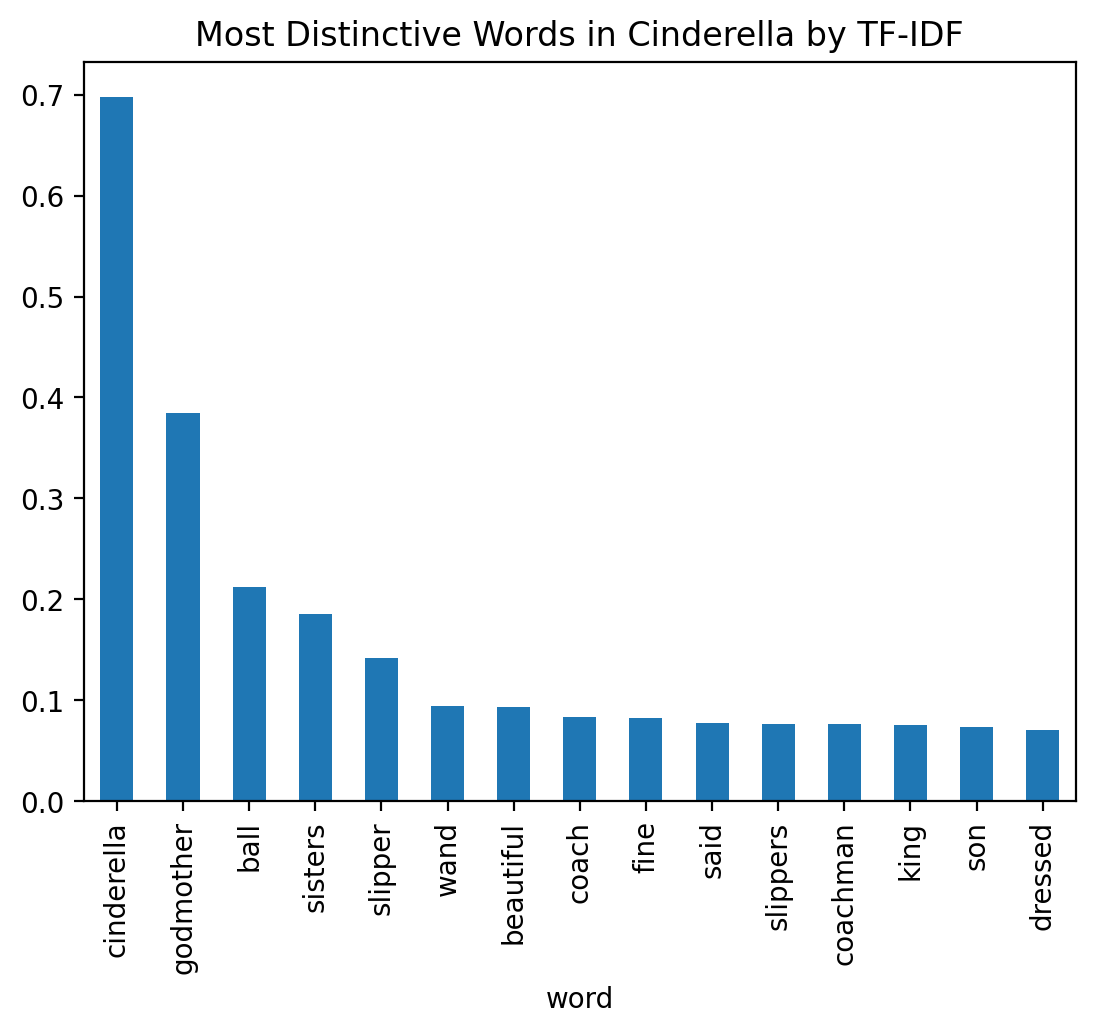

In [34]:
top_tfidf = important_words.sort_values(
    by="score",
    ascending=False
).head(15)

top_tfidf.plot.bar(
    x="word",
    y="score",
    legend=False,
    title="Most Distinctive Words in Cinderella by TF-IDF"
)

# Comparing Cinderella and Little Red Riding Hood

TF-IDF becomes especially useful when we compare documents.

Let's compare two familiar stories:

- Cinderella
- Little Red Riding Hood

We expect different stories to have different distinctive words.

In [35]:
little_red = folktales[
    folktales["Title"].str.contains(
        "Little Red",
        case=False,
        na=False
    )
]

little_red[["Title", "Country of Origin", "Author", "Story Type"]]

,Title,Country of Origin,Author,Story Type
18,Little Red Riding Hood,Germany,Jacob & Wilhelm Grimm,Little Red Riding Hood (ATU 333)
423,Little Red Riding Hood,France,Charles Perrault,Little Red Riding Hood (ATU 333)\n\t\t


In [36]:
# Select the first Little Red Riding Hood match
little_red_index = little_red.index[1]


In [37]:
# Get Cinderella TF-IDF scores
cinderella_scores = matrix[story_index].toarray()[0]

cinderella_tfidf = pd.DataFrame({
    "word": feature_names,
    "score": cinderella_scores
}).sort_values(
    by="score",
    ascending=False
).head(15)

cinderella_tfidf

,word,score
754,cinderella,0.697313
1880,godmother,0.384628
255,ball,0.212715
3945,sisters,0.185666
3979,slipper,0.142353
4772,wand,0.094327
308,beautiful,0.093909
807,coach,0.083051
1594,fine,0.082662
3689,said,0.078031


In [52]:
# Get Little Red Riding Hood TF-IDF scores
little_red_scores = matrix[little_red_index].toarray()[0]

little_red_tfidf = pd.DataFrame({
    "word": feature_names,
    "score": little_red_scores
}).sort_values(
    by="score",
    ascending=False
).head(15)

little_red_tfidf

,word,score
2154,hood,0.456463
1913,grandmother,0.419637
4917,wolf,0.365725
3583,riding,0.305306
2539,little,0.226362
3479,red,0.222231
599,cake,0.177792
583,butter,0.166112
4379,tap,0.148279
3267,pot,0.131108


## Visual Comparison

<Axes: title={'center': 'Distinctive Words in Cinderella'}, xlabel='word'>

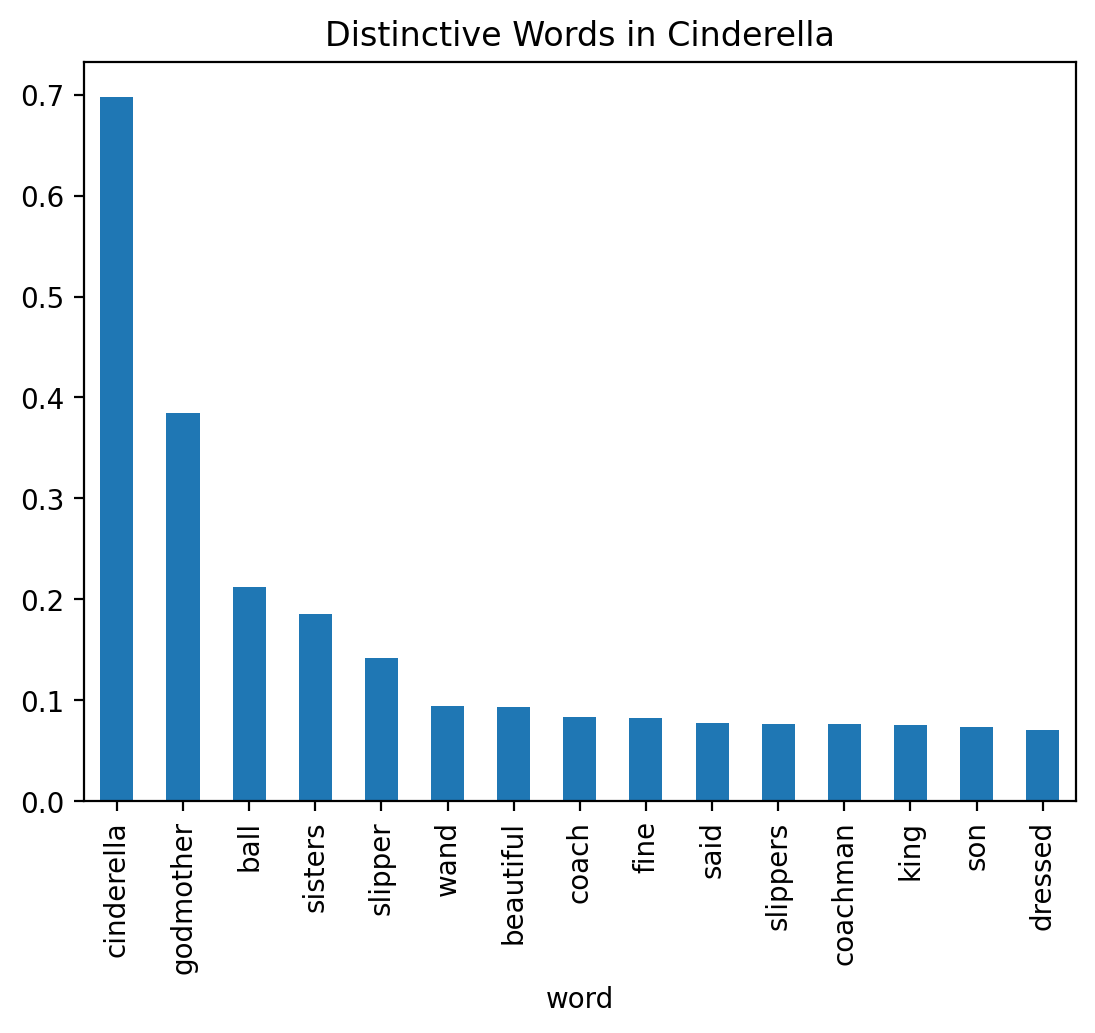

In [39]:
cinderella_tfidf.plot.bar(
    x="word",
    y="score",
    legend=False,
    title="Distinctive Words in Cinderella"
)

<Axes: title={'center': 'Distinctive Words in Little Red Riding Hood'}, xlabel='word'>

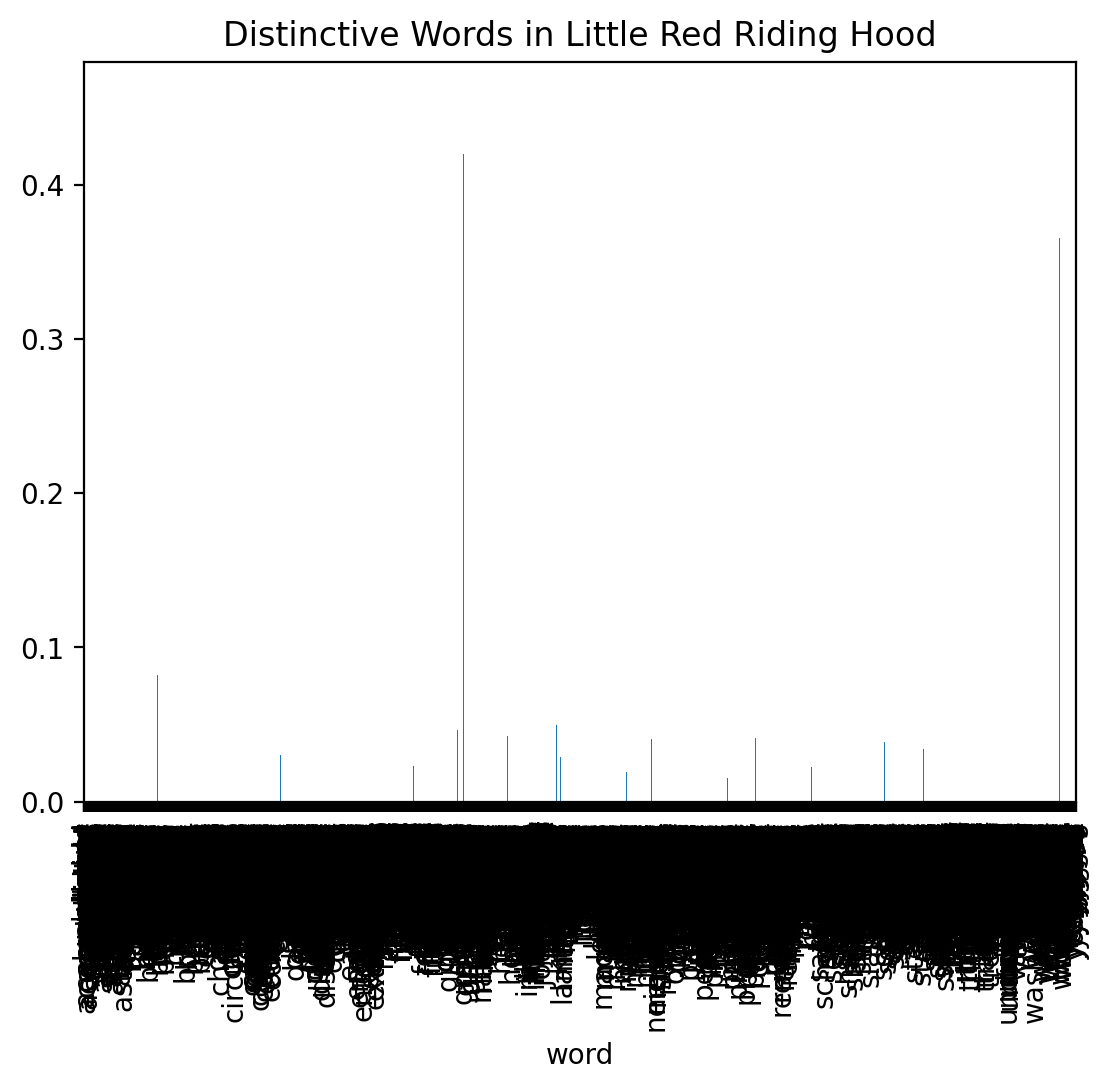

In [51]:
little_red_tfidf.plot.bar(
    x="word",
    y="score",
    legend=False,
    title="Distinctive Words in Little Red Riding Hood"
)

# You Try

Choose a different folktale and repeat the TF-IDF analysis.

In [41]:
folktales[["Title", "Country of Origin"]].sample(10)

,Title,Country of Origin
108,The donkey,Germany
390,Boots And His Crew,Norway
614,The Woman and Her Hen,Greece
537,The Ass and the Mule,Greece
704,The Cottager and his Cat,Iceland
730,The Proud Frog,Italy
820,The Horoscope,France
828,"The Two Rats, the Fox, and the Egg",France
313,The Prophetic Dream,Russia
691,The Ass in the Lion's Skin,Greece


In [42]:
# Change this title fragment to find a different story
title_fragment = "Wolf"

selected_story = folktales[
    folktales["Title"].str.contains(
        title_fragment,
        case=False,
        na=False
    )
]

selected_story[["Title", "Country of Origin", "Author"]].head()

,Title,Country of Origin,Author
1,The Wolf and the Seven Young Kids,Germany,Jacob & Wilhelm Grimm
58,The wolf and the man,Germany,Jacob & Wilhelm Grimm
59,The wolf and the fox,Germany,Jacob & Wilhelm Grimm
60,Gossip wolf and the fox,Germany,Jacob & Wilhelm Grimm
291,The Wolf and the Goat,Russia,Alexander Afanasyev


In [43]:
# If the search found at least one story, analyze the first match
selected_index = selected_story.index[0]

selected_scores = matrix[selected_index].toarray()[0]

selected_important_words = pd.DataFrame({
    "word": feature_names,
    "score": selected_scores
})

selected_important_words.sort_values(
    by="score",
    ascending=False
).head(20)

,word,score
4917,wolf,0.500400
2351,kids,0.367589
2806,mother,0.272554
3079,paws,0.229282
726,children,0.163482
1247,door,0.156307
1096,dear,0.151130
2748,miller,0.149938
991,cried,0.143710
2135,hoarse,0.135014


# Simple Sentiment Analysis

Another common text analysis task is sentiment analysis.

This attempts to estimate whether text is:

- positive
- negative
- neutral

Sentiment analysis is useful, but it is also imperfect. It can struggle
with sarcasm, context, older language, and cultural nuance.

In [44]:
from textblob import TextBlob

In [45]:
reviews["sentiment"] = reviews["Review"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

reviews[["Apartment","Stars","sentiment"]]

,Apartment,Stars,sentiment
0,Mustang Station,2,0.146667
1,Campus View,4,0.086111
2,Highland House,1,0.090909
3,Mockingbird Flats,5,0.333333
4,Hilltop Lofts,3,-0.116667
5,University Crossing,2,0.066667
6,Maple Terrace,4,0.180952
7,Lakeside Apartments,1,0.000000


<Axes: title={'center': 'Estimated Review Sentiment'}, xlabel='Apartment'>

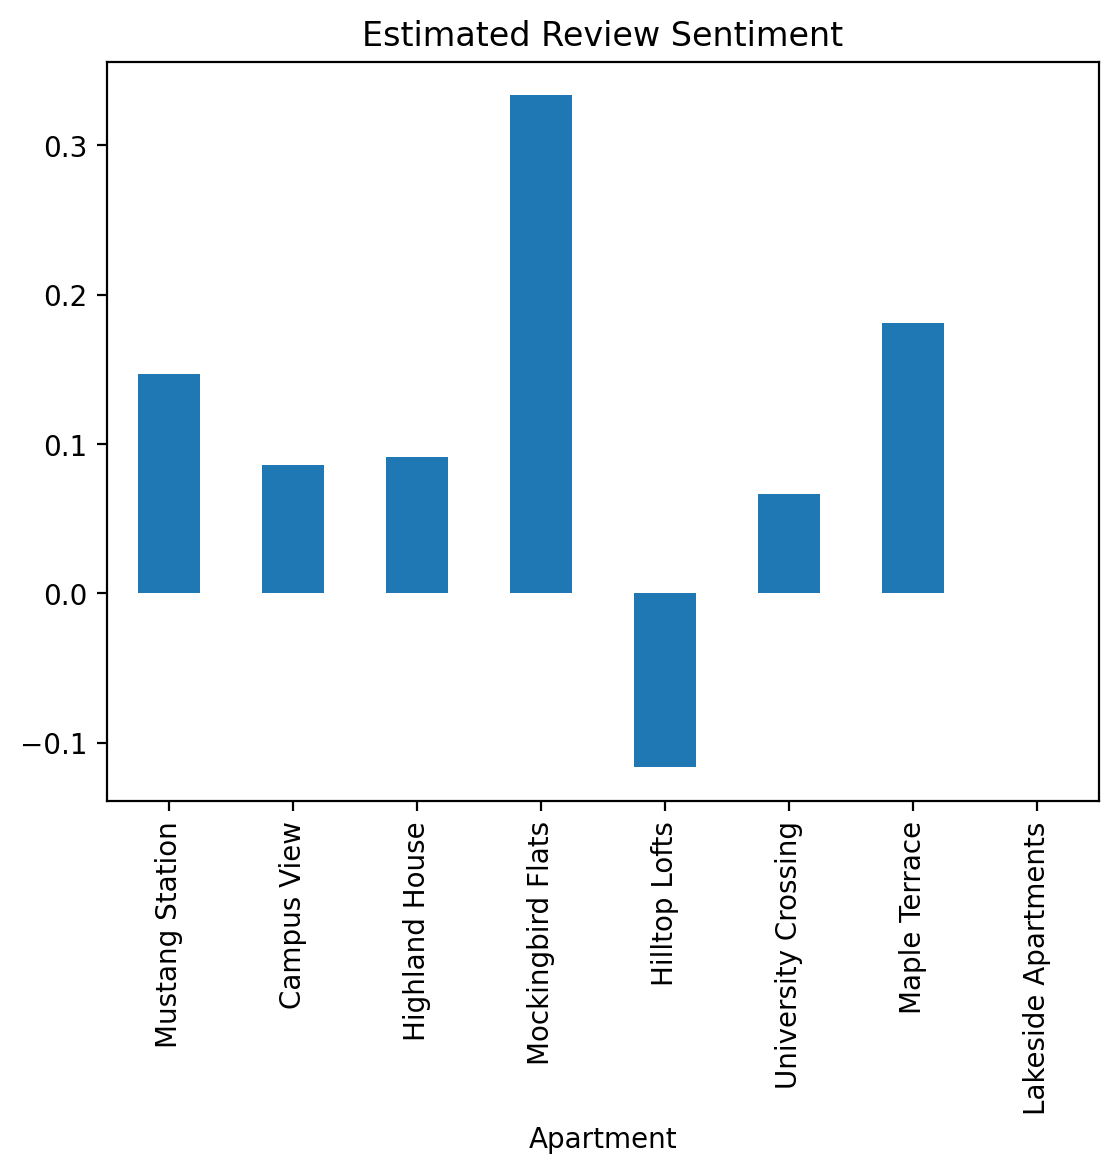

In [46]:
reviews.plot.bar(
    x="Apartment",
    y="sentiment",
    legend=False,
    title="Estimated Review Sentiment"
)

# Sentiment in Folktales

In [47]:
folktales["sentiment"] = folktales["Story"].fillna("").apply(
    lambda x: TextBlob(x).sentiment.polarity
)

folktales[["Title", "Country of Origin", "sentiment"]].sort_values(
    by="sentiment",
    ascending=False
).head(10)

,Title,Country of Origin,sentiment
513,The Boy Hunting Locusts,Greece,0.875000
735,The Kite and the Doves,Italy,0.800000
562,The Man Bitten by a Dog,Greece,0.700000
671,The Wolf and the Lion,Greece,0.625000
745,The Cock and the Pearl,Italy,0.566667
847,The Rooster and the Gem,France,0.556250
602,The Fox and the Leopard,Greece,0.540000
750,The Trees Protected,Italy,0.529762
535,The Lioness,Greece,0.529167
607,The Shepherd and the Dog,Greece,0.500000


In [48]:
folktales[["Title", "Country of Origin", "sentiment"]].sort_values(
    by="sentiment",
    ascending=True
).head(10)

,Title,Country of Origin,sentiment
77,Old Hildebrand,Germany,-0.345443
670,The Fox and the Bramble,Greece,-0.333333
647,The Gamecocks and the Partridge,Greece,-0.323611
505,The Boy Bathing,Greece,-0.312500
531,The Thirsty Pigeon,Greece,-0.310000
665,Truth and the Traveler,Greece,-0.300000
693,The Frogs' Complaint Against the Sun,Greece,-0.299286
726,The Hungry Dogs,Italy,-0.275000
565,The Aethiop,Greece,-0.255556
773,The Viper and the File,Italy,-0.237500


# Limitations of Text Analysis

Text analysis is powerful, but imperfect.

Some challenges include:

- sarcasm
- ambiguity
- context
- cultural meaning
- humor
- changing language
- translation
- historical language
- missing metadata

Simple methods often lose important meaning.

# AI and Modern Language Models

Many modern AI systems use ideas related to text analysis.

Older approaches:

- counted words
- measured frequencies
- used simple statistics

Modern AI systems:

- model context
- learn relationships between words
- represent language mathematically
- generate new text

Large Language Models are built on these kinds of ideas, but at much
larger scales.

# AI Assistant Checkpoint

Try asking an AI assistant:

- “Explain TF-IDF in plain English.”
- “Why do we remove stopwords in text analysis?”
- “What meaning is lost when we use word counts?”
- “How could I improve this text analysis?”
- “Why might sentiment analysis fail on folktales?”

# Mini Challenge

Choose one folktale or the apartment review set and investigate it.

Try to:

- clean the text
- count important words
- generate bigrams
- calculate TF-IDF
- visualize something interesting

Then answer:

1.  What pattern did you notice?
2.  What surprised you?
3.  What important meaning might your analysis miss?